In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Generating the synthetic dataset

In [2]:
np.random.seed(42)

n_samples = 2000

temperature = np.random.normal(loc=350, scale=15, size=n_samples)
pressure = np.random.normal(loc=8, scale=1.5, size=n_samples)
flow_rate = np.random.normal(loc=120, scale=20, size=n_samples)
level = np.random.uniform(40, 90, size=n_samples)

def hazop_risk(temp, press):
    if temp > 380 and press > 10:
        return "High"
    elif temp > 365 or press > 9:
        return "Medium"
    else:
        return "Low"

risk_label = [hazop_risk(t, p) for t, p in zip(temperature, pressure)]

df = pd.DataFrame({
    "Temperature": temperature,
    "Pressure": pressure,
    "FlowRate": flow_rate,
    "Level": level,
    "Risk": risk_label
})

df.to_csv("synthetic_refinery_data.csv", index=False)

print(df.head())

   Temperature  Pressure    FlowRate      Level    Risk
0   357.450712  6.987233  102.730128  56.822518     Low
1   347.926035  7.783222  119.375930  50.560413     Low
2   359.715328  6.811370  120.360337  55.659103     Low
3   372.845448  7.538058  129.452607  48.942053  Medium
4   346.487699  5.159578   92.662833  85.095805     Low


Pre Processing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [4]:
# Features and target
X = df[["Temperature", "Pressure", "FlowRate", "Level"]]
y = df["Risk"]


# Encode labels if they are strings (e.g. "Low", "Medium", "High")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([1, 1, 1, ..., 1, 2, 1], shape=(2000,))

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Xgboost

In [6]:
# Create XGBoost classifier
model = XGBClassifier(
    objective="multi:softprob",   # multi-class classification
    num_class=len(label_encoder.classes_),
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)


In [7]:
# Train
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [8]:
# Predict
y_pred = model.predict(X_test)


In [9]:
# Decode predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test_labels, y_pred_labels))

Accuracy: 0.9975
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       1.00      1.00      1.00       251
      Medium       0.99      1.00      1.00       148

    accuracy                           1.00       400
   macro avg       0.66      0.67      0.67       400
weighted avg       1.00      1.00      1.00       400



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [11]:
import xgboost as xgb
import matplotlib.pyplot as plt

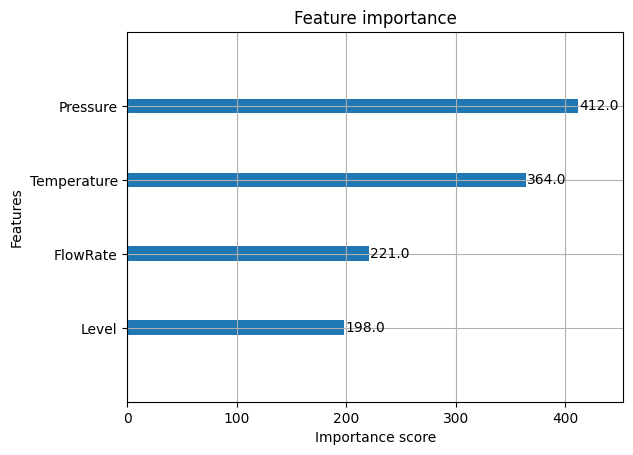

In [13]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

In [14]:
from collections import Counter

print(Counter(y_encoded))

Counter({np.int64(1): 1255, np.int64(2): 741, np.int64(0): 4})
